# Day 08. Exercise 03
# Overfitting

## Imports

In [1]:
import numpy as np
import pandas as pd
import joblib as jbl
from sklearn.svm import SVC
from scipy.stats import randint
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier

## Preprocessing

In [2]:
df = pd.read_csv('../data/dayofweek.csv')
x = df.drop(columns=df[['dayofweek']])
y = df['dayofweek']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    random_state=21,
    test_size=0.2
)
print(f'train:\n{y_train.value_counts()}\n\ntest:\n{y_test.value_counts()}')

train:
dayofweek
3    313
6    287
1    222
5    216
2    125
0    105
4     80
Name: count, dtype: int64

test:
dayofweek
3    83
6    69
5    55
1    52
0    31
4    24
2    24
Name: count, dtype: int64


In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    random_state=21,
    test_size=0.2,
    stratify=y
)
print(f'train:\n{y_train.value_counts()}\n\ntest:\n{y_test.value_counts()}')

train:
dayofweek
3    316
6    285
1    219
5    217
2    119
0    109
4     83
Name: count, dtype: int64

test:
dayofweek
3    80
6    71
1    55
5    54
2    30
0    27
4    21
Name: count, dtype: int64


## Baseline models

In [4]:
def train(model):
    model.fit(x_train, y_train)
    return accuracy_score(model.predict(x_test), y_test)

In [5]:
dummy = DummyClassifier(strategy='most_frequent')

train(dummy)

0.23668639053254437

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=21, fit_intercept=False, C=2),
    'SVM': OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21)),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=21),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
}
for name, model in models.items():
    print(f'Accuracy of {name}: {train(model)}')

Accuracy of Logistic Regression: 0.6272189349112426
Accuracy of SVM: 0.6183431952662722
Accuracy of Decision Tree: 0.5295857988165681


/home/jarvis/pandasvenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy of Random Forest: 0.9289940828402367


>***Все ли модели показали одинаковые значения показателя?***
>***Какая из них имеет наибольшую разницу по сравнению с текущим упражнением и предыдущим?***
>
> Значения с предыдущим днем у всех моделей кроме **дерева решений (decision tree) (C) и случайного леса (random forest)** практически одинаковы
>
> Ответ: **Random forest, C**

## Crossvalidation

In [7]:
def calc_accur(score):
    print(f'Mean accuracy: {score.mean()}')
    print(f'Standard deviation: {score.std()}')

In [8]:
for name, model in models.items():

    score = cross_val_score(model, x_train, y_train, cv=10, scoring="accuracy")
    print(f'Accuracy for {name}')
    calc_accur(score)
    print('\n')

Accuracy for Logistic Regression
Mean accuracy: 0.5949695964621338
Standard deviation: 0.024143922144436142




/home/jarvis/pandasvenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/jarvis/pandasvenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/jarvis/pandasvenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another s

Accuracy for SVM
Mean accuracy: 0.5705085682697624
Standard deviation: 0.037010421284044116


Accuracy for Decision Tree
Mean accuracy: 0.5088944168048645
Standard deviation: 0.031903139495514356


Accuracy for Random Forest
Mean accuracy: 0.9176561636263129
Standard deviation: 0.02159583796321821




## Optimization

> Самая лучшая модель?
>
> Ответ: Random forest

In [9]:
# n_calls = []
# n_estimators = []
# max_depth = []
# mix = []
# for i in range(1,70):
#     n_calls.append(i)
#     r_forest = RandomForestClassifier(n_estimators=i, max_depth=25, random_state=21)
#     n_estimators.append(train(r_forest))

#     r_forest = RandomForestClassifier(n_estimators=100, max_depth=i, random_state=21)
#     max_depth.append(train(r_forest))

#     r_forest = RandomForestClassifier(n_estimators=i, max_depth=i, random_state=21)
#     mix.append(train(r_forest))

# res = pd.DataFrame({
#     'n_calls': n_calls,
#     'n_estimators': n_estimators,
#     'max_depth': max_depth,
#     'mix_factor': mix
# })
# res.tail(20)

In [10]:
def plot(coef, features, n=10):
    importance = np.sum(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    sort_indices = np.argsort(importance)[-n:]
    plt.barh(features[sort_indices], importance[sort_indices])

Лучшие параметры: {'n_estimators': 90, 'max_depth': 66}
Лучшая точность: 0.9161746821448314


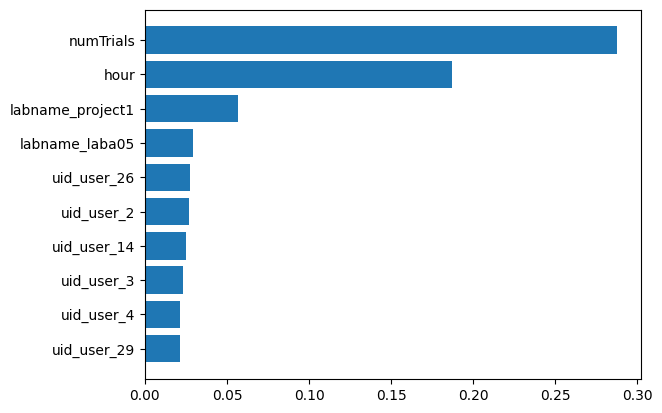

In [11]:
r_forest = RandomForestClassifier(random_state=21)
param_dist = {
    'n_estimators': range(50, 100),
    'max_depth': range(50, 100),
}
r_model = RandomizedSearchCV(r_forest, param_distributions=param_dist, random_state=21, cv=10, n_jobs=10)
train(r_model)

best_forest = r_model.best_estimator_

print(f"Лучшие параметры: {r_model.best_params_}")
print(f"Лучшая точность: {r_model.best_score_}")

plot(best_forest.feature_importances_, x.columns)

In [12]:
jbl.dump(best_forest, 'r_forest.joblib')

['r_forest.joblib']

In [13]:
model = jbl.load('r_forest.joblib')
y_predict = model.predict(x_test)
accuracy_score(y_test, y_predict)

0.9378698224852071